# Safe Haven Assets Post-COVID: An Empirical Assessment of Hedging Properties

**Course:** Empirical Methods in Finance  
**Authors:** *[Names]*  
**Date:** May 2026

---

## Abstract

*[To be written after results are finalized.]*

---

## 0. Imports & Setup

All packages installed below. `arch` provides GJR-GARCH and GARCH estimation.
`ruptures` implements the Bai-Perron dynamic-programming algorithm. `statsmodels`
provides the Markov-switching filter (Hamilton 1989) and time-series diagnostics.

In [1]:
import subprocess
subprocess.run(['pip', 'install', 'arch', 'ruptures', 'scikit-learn'], capture_output=True)

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from scipy import stats
from scipy.stats import jarque_bera, kstest, norm
from scipy.optimize import minimize

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

from arch import arch_model
import ruptures as rpt

warnings.filterwarnings('ignore')
np.random.seed(42)

os.makedirs('outputs/figures', exist_ok=True)
os.makedirs('outputs/tables',  exist_ok=True)

# ── Global parameters (one place to change everything) ────────────────────────
COVID_DATE   = pd.Timestamp('2020-03-11')   # WHO pandemic declaration
SPLIT_DATE   = '2020-03-01'                 # provisional pre/post split
DURATION_10Y = 8.5                           # modified duration for 10Y bond return proxy
TRIM         = 0.15                          # Andrews (1993) trimming fraction
SUPF_CV_5PCT = 8.85                          # Andrews 5% critical value, k=1 restriction
MIN_SEG_BP   = 252                           # Bai-Perron minimum segment = 1 year of daily obs
ROLL_WIN     = 252                           # rolling correlation window (1 year, daily)
OOS_CUTOFF   = '2020-01-01'                  # out-of-sample cutoff for volatility tournament
MS_PRE_START = '2010-01-01'                  # MS pre-COVID window start (excludes 2008 GFC)

safe_havens = ['Gold', 'US10Y', 'USDCHF', 'USDJPY']
benchmarks  = ['SP500', 'Eurostoxx50']       # test vs BOTH equity benchmarks


#### justification cste TRIM
!!!!text pure IA!!!! 
Following Andrews (1993), we set the trimming fraction to 15% in the sup-F test applied in Step 4.2 to each DCC correlation series, meaning the test searches for breaks only within the central 70% of the sample. The value of 15% is not arbitrary: Andrews (1993) derived it as the practical optimum balancing the risk of boundary noise against the cost of shrinking the search region, and it has since become the standard convention in applied structural break testing, adopted notably by Bai and Perron (1998, 2003) in their multiple-break extension. In our application this choice has no material consequence, since the COVID-19 event of March 2020 falls well within the interior of our 1990–2026 sample, far from either trimmed boundary.

---

# 1. Data & Stylized Facts

## Step 1.1 — Data Loading & Sign Conventions

Six assets from `data/Data.xlsx`. We compute log-returns with the following sign
conventions so that **a positive value always represents a profit for the holder**
(or safe-haven appreciation):

| Asset | Transformation |
|---|---|
| S&P 500, Eurostoxx 50, Gold | $\ln(P_t / P_{t-1})$ |
| US 10Y yield | $-\Delta y_t \times D_{\text{mod}} / 100$ (duration approximation; positive = bond price rises) |
| USDCHF, USDJPY | $-\ln(P_t / P_{t-1})$ (CHF/JPY appreciation as positive) |

**Critical note on data loading:** we compute log-returns *before* any forward-filling
so that we only work with actual trading-day returns. Forward-filling prices before
computing returns would create artificial zero-return observations on non-trading days,
distorting GARCH estimates, ACF diagnostics, and rolling correlations. After computing
returns, we drop rows with any remaining missing value.

Returns are multiplied by 100 (percentage points) for numerical stability in GARCH
estimation. The provisional pre/post split uses **2020-03-01** and is later confirmed
endogenously by Bai-Perron.

In [2]:
COLS = {
    'S&P500':             'SP500',
    'Eurostoxx 50':       'Eurostoxx50',
    'Gold':               'Gold',
    'US T 10-year Yield': 'US10Y_yield',   # raw yield level
    'USDCHF':             'USDCHF',
    'USDJPY':             'USDJPY',
}

# Load raw daily prices — no ffill yet, we want actual prices
raw = (pd.read_excel(Path("data/Data.xlsx"), index_col=0, parse_dates=True)
         [list(COLS.keys())]
         .rename(columns=COLS))

# ── Compute returns on actual prices BEFORE any filling ───────────────────────
returns = pd.DataFrame(index=raw.index)
returns['SP500']       = np.log(raw['SP500']       / raw['SP500'].shift(1))
returns['Eurostoxx50'] = np.log(raw['Eurostoxx50'] / raw['Eurostoxx50'].shift(1))
returns['Gold']        = np.log(raw['Gold']         / raw['Gold'].shift(1))

# Duration approximation: ΔP/P ≈ -D_mod × Δy_decimal
# DURATION_10Y = 8.5 years is a central estimate; see limitations in report.
returns['US10Y']  = -raw['US10Y_yield'].diff() * DURATION_10Y / 100

# Negate FX returns: falling USDCHF/USDJPY = foreign currency appreciating = safe-haven response
returns['USDCHF'] = -np.log(raw['USDCHF'] / raw['USDCHF'].shift(1))
returns['USDJPY'] = -np.log(raw['USDJPY'] / raw['USDJPY'].shift(1))

# Drop rows with any NaN (actual missing trading days, first row after shift)
returns = returns.dropna() * 100   # scale to percentage points

# ── Pre / post split ──────────────────────────────────────────────────────────
ret_pre  = returns.loc[:SPLIT_DATE]
ret_post = returns.loc[SPLIT_DATE:]

print(f"Full sample : {returns.index[0].date()} → {returns.index[-1].date()} ({len(returns):,} obs)")
print(f"Pre-COVID   : {ret_pre.index[0].date()} → {ret_pre.index[-1].date()} ({len(ret_pre):,} obs)")
print(f"Post-COVID  : {ret_post.index[0].date()} → {ret_post.index[-1].date()} ({len(ret_post):,} obs)")
print(f"\nAll assets  : {list(returns.columns)}")

Full sample : 1990-01-03 → 2026-04-24 (8,476 obs)
Pre-COVID   : 1990-01-03 → 2020-02-28 (7,038 obs)
Post-COVID  : 2020-03-03 → 2026-04-24 (1,438 obs)

All assets  : ['SP500', 'Eurostoxx50', 'Gold', 'US10Y', 'USDCHF', 'USDJPY']


## Step 1.2 — Descriptive Statistics

Annualized mean and volatility, skewness, excess kurtosis, max drawdown, and four
diagnostic tests:

- **Jarque-Bera / Kolmogorov-Smirnov**: normality — we expect rejection, motivating the
  Student-t distribution in the GJR-GARCH.
- **ADF + KPSS**: stationarity — we need $p_{\text{ADF}} < 0.05$ and $p_{\text{KPSS}} > 0.05$
  to confirm the series are $I(0)$, a prerequisite for valid OLS and GARCH inference.
- **Ljung-Box on squared returns**: ARCH effects — a very small p-value means squared
  returns are autocorrelated, which is the empirical motivation for GARCH.

In [3]:
def stylized_facts(df, label):
    stats_df = pd.DataFrame(index=df.columns)
    stats_df['Mean (ann %)'] = df.mean() * 252
    stats_df['Vol (ann %)']  = df.std()  * np.sqrt(252)
    stats_df['Skewness']     = df.skew()
    stats_df['Excess kurt']  = df.kurtosis()
    stats_df['Max DD %']     = (
        (1 + df / 100).cumprod() / (1 + df / 100).cumprod().cummax() - 1
    ).min() * 100

    jb, ks_p, adf_p, kpss_p, lb_p = [], [], [], [], []
    for col in df.columns:
        s = df[col].dropna()
        jb.append(jarque_bera(s)[1])
        ks_p.append(kstest(s, 'norm', args=(s.mean(), s.std()))[1])
        adf_p.append(adfuller(s)[1])
        kpss_p.append(kpss(s, regression='c', nlags='auto')[1])
        lb_p.append(acorr_ljungbox(s**2, lags=[10], return_df=True)['lb_pvalue'].iloc[0])

    stats_df['JB p']   = jb
    stats_df['KS p']   = ks_p
    stats_df['ADF p']  = adf_p
    stats_df['KPSS p'] = kpss_p
    stats_df['LB² p']  = lb_p
    print(f"\n{'═'*60}\n{label}\n{'═'*60}")
    return stats_df.round(4)

table1_pre  = stylized_facts(ret_pre,  "Pre-COVID")
display(table1_pre)
table1_post = stylized_facts(ret_post, "Post-COVID")
display(table1_post)

table1_pre.to_csv('outputs/tables/table1_pre.csv')
table1_post.to_csv('outputs/tables/table1_post.csv')


════════════════════════════════════════════════════════════
Pre-COVID
════════════════════════════════════════════════════════════


,Mean (ann %),Vol (ann %),Skewness,Excess kurt,Max DD %,JB p,KS p,ADF p,KPSS p,LB² p
SP500,5.7410,17.1718,-0.3426,7.5351,-65.1466,0.0,0.0,0.0,0.1,0.0000
Eurostoxx50,0.6084,20.6233,-0.1812,4.9312,-78.2827,0.0,0.0,0.0,0.1,0.0000
Gold,5.2920,15.6399,-0.1568,8.5108,-49.0414,0.0,0.0,0.0,0.1,0.0000
US10Y,2.7241,7.8600,-0.0574,2.0209,-18.3418,0.0,0.0,0.0,0.1,0.0000
USDCHF,2.5475,11.3485,2.9350,78.2288,-33.5153,0.0,0.0,0.0,0.1,0.6884
USDJPY,1.3971,10.6499,0.3602,5.6308,-39.0009,0.0,0.0,0.0,0.1,0.0000



════════════════════════════════════════════════════════════
Post-COVID
════════════════════════════════════════════════════════════


,Mean (ann %),Vol (ann %),Skewness,Excess kurt,Max DD %,JB p,KS p,ADF p,KPSS p,LB² p
SP500,14.5066,20.9579,-0.6685,15.3471,-30.5669,0.0,0.0000,0.0,0.1,0.0
Eurostoxx50,8.9624,20.4879,-0.8637,13.0073,-31.5502,0.0,0.0000,0.0,0.1,0.0
Gold,17.3470,17.6418,-0.6223,6.2934,-18.1361,0.0,0.0000,0.0,0.1,0.0
US10Y,-2.6486,8.2471,0.1268,2.3621,-29.3989,0.0,0.0234,0.0,0.1,0.0
USDCHF,4.5459,7.9672,0.5907,4.2700,-11.7354,0.0,0.0069,0.0,0.1,0.0
USDJPY,-4.4632,9.6861,0.4039,4.4188,-31.5732,0.0,0.0000,0.0,0.1,0.0


## Step 1.3 — ACF of Returns and Squared Returns

If the ACF of $r_t$ shows little autocorrelation but the ACF of $r_t^2$ decays
slowly, this is the signature of **volatility clustering**: large moves tend to
follow large moves regardless of sign. This visual evidence motivates the GARCH
family. Note: even if we knew $\sigma_t^2$ exactly, $r_t^2$ would fall within
$\pm 50\%$ of the true variance only about 26% of the time (under $\chi^2(1)$),
which is why a model-based filter is needed.

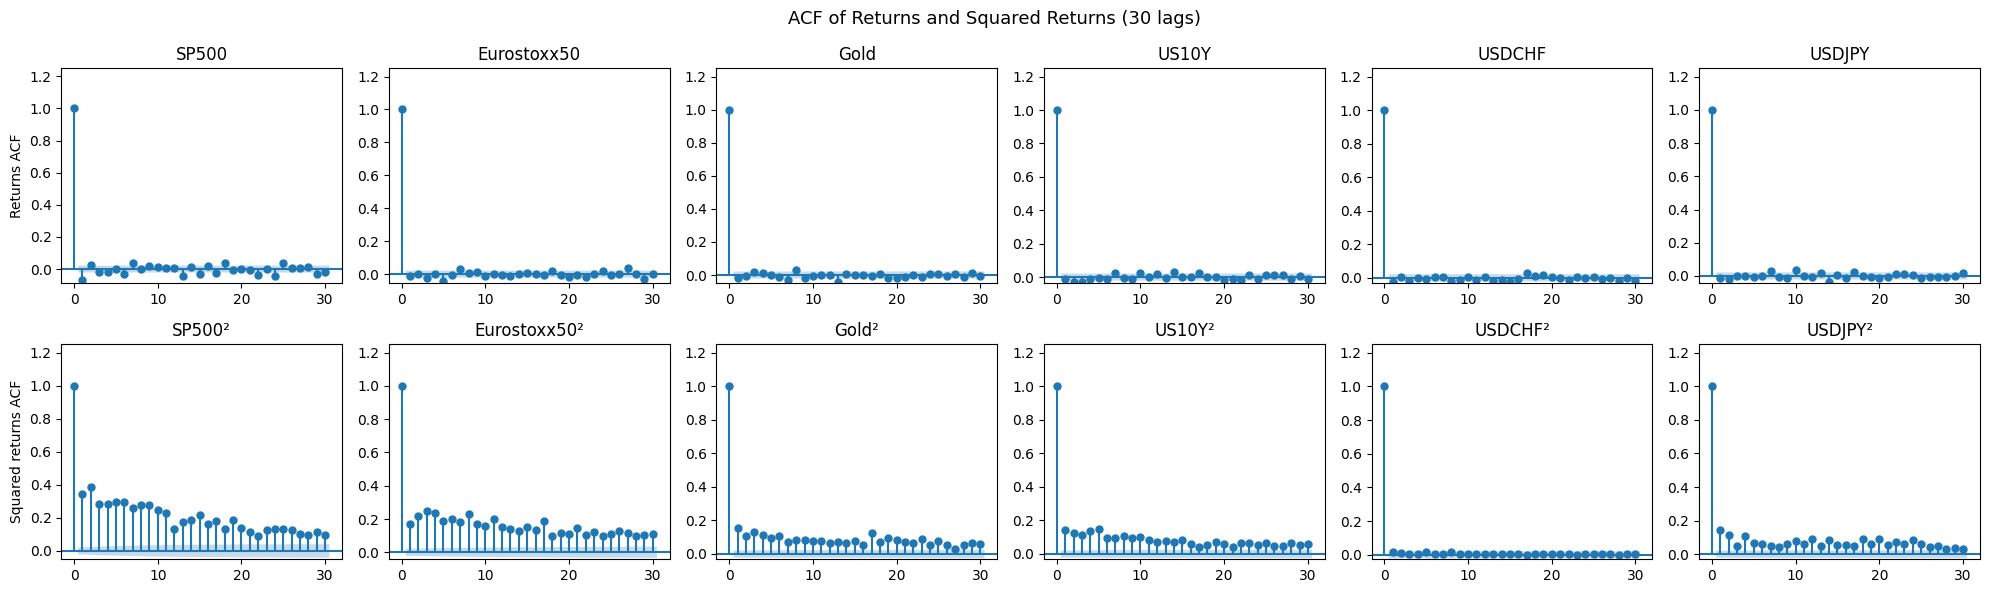

In [4]:
fig, axes = plt.subplots(2, len(returns.columns), figsize=(20, 6))
for i, col in enumerate(returns.columns):
    plot_acf(returns[col],      ax=axes[0, i], lags=30, title=col,     auto_ylims=True)
    plot_acf(returns[col] ** 2, ax=axes[1, i], lags=30, title=f"{col}²", auto_ylims=True)
axes[0, 0].set_ylabel('Returns ACF')
axes[1, 0].set_ylabel('Squared returns ACF')
plt.suptitle('ACF of Returns and Squared Returns (30 lags)', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/figures/acf.png', dpi=150, bbox_inches='tight')
plt.show()

---

# 2. Univariate Volatility Modelling

We fit a **GJR-GARCH(1,1)-t** to each asset on three samples: full, pre-COVID,
and post-COVID. The goals are:

1. Produce the full-sample conditional volatility $\hat{\sigma}_t$ used as input
   to the DCC filter in Block 3.
2. Compare pre vs post parameters (Table 2) to document whether volatility dynamics
   shifted structurally around COVID.
3. Formally test whether **persistence** changed significantly (Wald test, Step 2.3).
4. Run a **sup-F test on $\hat{\sigma}_t$** (Step 2.4) as a motivational structural
   break test: if volatility itself is unstable post-2008, this justifies the deeper
   investigation of correlation breaks via Bai-Perron in Block 4.

## Step 2.1 — GJR-GARCH(1,1)-t Definition

$$\sigma_t^2 = \omega + \alpha\,\varepsilon_{t-1}^2 + \gamma\,\varepsilon_{t-1}^2\,\mathbf{1}_{\{\varepsilon_{t-1}<0\}} + \beta\,\sigma_{t-1}^2, \qquad z_t \sim t_\nu$$

A significant positive $\gamma$ captures the leverage effect. The Student-t handles fat tails via $\nu$. Persistence $= \alpha + \frac{\gamma}{2} + \beta$ measures how long a volatility shock survives.

In [5]:
# ── GJR-GARCH(1,1)-t ─────────────────────────────────────────────────────────
def fit_gjr(series):
    return arch_model(series, vol='GARCH', p=1, o=1, q=1, dist='studentst').fit(disp='off')


## Step 2.2 — Estimate GJR-GARCH: Full Sample and Pre/Post

Two sets of fits. The **full-sample** conditional volatility feeds the DCC filter in
Block 3. The **pre/post** fits are compared in Table 2 — a change in $\gamma$, $\nu$,
or persistence across the COVID break is motivational evidence that safe-haven volatility
dynamics shifted.

Pre-COVID                                              Post-COVID  \
                omega   alpha   gamma    beta       nu persistence      omega   
SP500          0.0153  0.0137  0.1617  0.8910   6.5823      0.9856     0.0346   
Eurostoxx50    0.0229  0.0168  0.1482  0.8934   7.8366      0.9843     0.0642   
Gold           0.0024  0.0680 -0.0388  0.9513   4.6840      1.0000     0.0371   
US10Y          0.0013  0.0421 -0.0138  0.9598  10.9959      0.9949     0.0051   
USDCHF         0.0020  0.0403 -0.0027  0.9573   6.9855      0.9962     0.0159   
USDJPY         0.0040  0.0557 -0.0134  0.9435   5.2853      0.9925     0.0086   

                                                          
              alpha   gamma    beta       nu persistence  
SP500        0.0000  0.2015  0.8626   6.8861      0.9634  
Eurostoxx50  0.0000  0.2342  0.8348   5.7466      0.9519  
Gold         0.1071 -0.0752  0.9008   5.6922      0.9702  
US10Y        0.0734  0.0423  0.8862  13.1211      0.9808  
USDCHF       0.0553 -0.0072  0.8795   7.3301      0.9312  
USDJPY       0.1061 -0.0307  0.8873   5.0108      0.9781

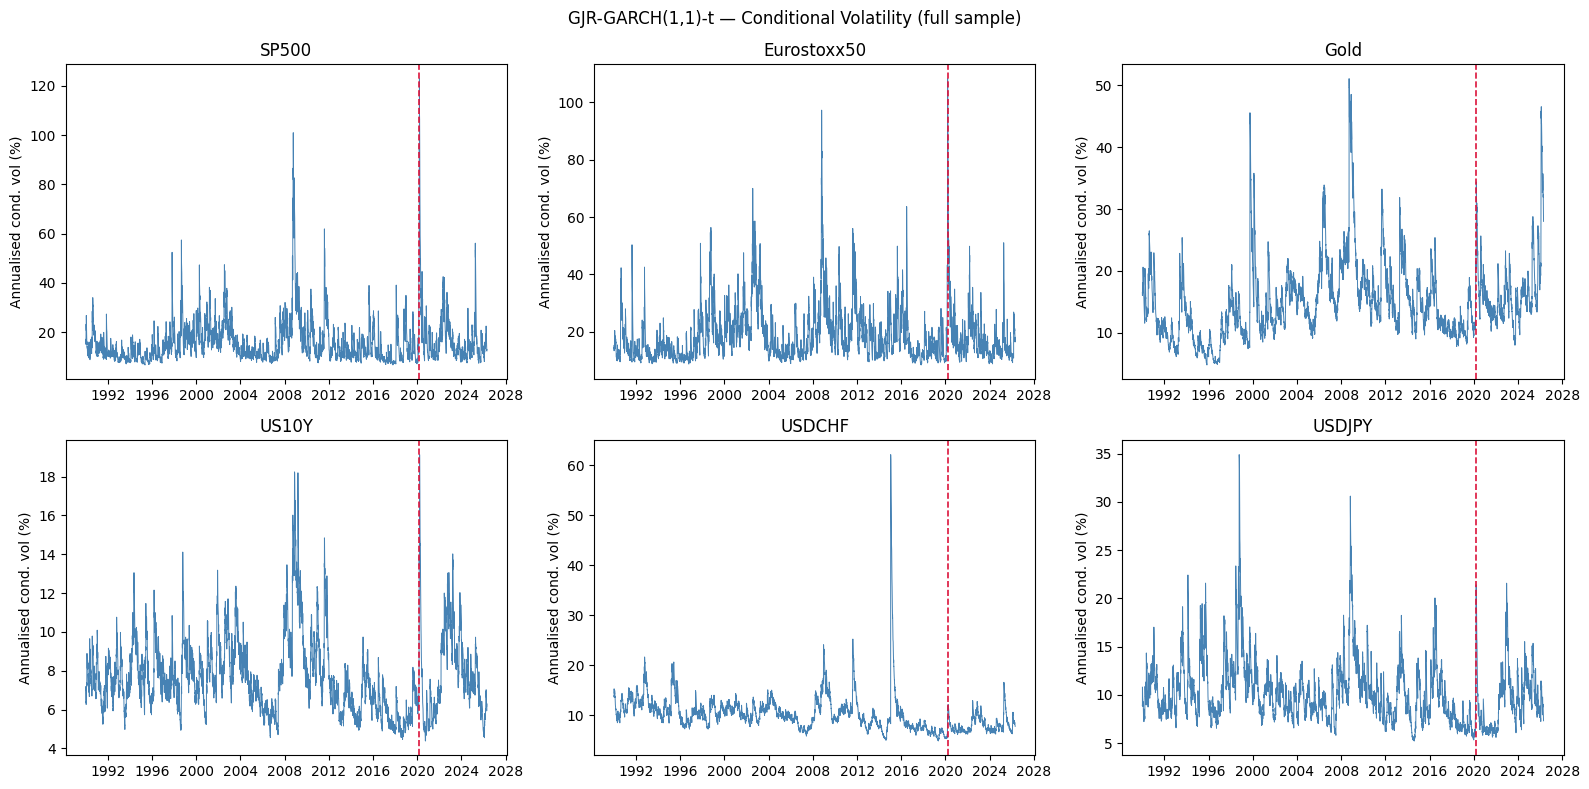

In [6]:
# Full-sample fits (conditional vol used in DCC)
garch_full = {col: fit_gjr(returns[col]) for col in returns.columns}
# Pre / post fits (for parameter comparison)
garch_pre  = {col: fit_gjr(ret_pre[col])  for col in returns.columns}
garch_post = {col: fit_gjr(ret_post[col]) for col in returns.columns}

def garch_summary(model_dict, label):
    rows = []
    for col, res in model_dict.items():
        p = res.params
        rows.append({
            'omega':       p['omega'],
            'alpha':       p['alpha[1]'],
            'gamma':       p['gamma[1]'],
            'beta':        p['beta[1]'],
            'nu':          p['nu'],
            'persistence': p['alpha[1]'] + 0.5*p['gamma[1]'] + p['beta[1]'],
        })
    df = pd.DataFrame(rows, index=model_dict.keys()).round(4)
    df.columns = pd.MultiIndex.from_product([[label], df.columns])
    return df

table2 = pd.concat([
    garch_summary(garch_pre,  'Pre-COVID'),
    garch_summary(garch_post, 'Post-COVID')
], axis=1)
display(table2)
table2.to_csv('outputs/tables/table2_gjr_params.csv')

# ── Conditional volatility plot ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, returns.columns):
    ax.plot(garch_full[col].conditional_volatility * np.sqrt(252),
            linewidth=0.7, color='steelblue')
    ax.axvline(COVID_DATE, color='crimson', linestyle='--', linewidth=1.2)
    ax.set_title(col)
    ax.set_ylabel('Annualised cond. vol (%)')
plt.suptitle('GJR-GARCH(1,1)-t — Conditional Volatility (full sample)', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/figures/conditional_vol.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 2.3 — GARCH Diagnostics

Ljung-Box on squared standardized residuals $(\hat{z}_t^2 = (\hat{\varepsilon}_t / \hat{\sigma}_t)^2)$
at lag 10. A p-value above 0.05 means the GARCH has absorbed the ARCH effects — the
model is well specified.

In [7]:
print("Ljung-Box on squared standardized residuals (p > 0.05 = well specified):")
for col, res in garch_full.items():
    z2 = (res.resid / res.conditional_volatility).dropna() ** 2
    p  = acorr_ljungbox(z2, lags=[10], return_df=True)['lb_pvalue'].iloc[0]
    flag = '✓' if p > 0.05 else '✗ ARCH remains'
    print(f"  {col:12s}  p = {p:.4f}  {flag}")

Ljung-Box on squared standardized residuals (p > 0.05 = well specified):
  SP500         p = 0.6776  ✓
  Eurostoxx50   p = 0.7455  ✓
  Gold          p = 0.0000  ✗ ARCH remains
  US10Y         p = 0.0701  ✓
  USDCHF        p = 1.0000  ✓
  USDJPY        p = 0.7183  ✓


## Step 2.3b — Wald Test: Did Persistence Change Significantly?

Reporting pre vs post persistence numbers in Table 2 is purely descriptive.
We now test formally whether the difference is statistically significant.

Define persistence for a GJR-GARCH as the scalar:

$$\pi = \alpha + \frac{\gamma}{2} + \beta$$

Since the pre and post subsamples are **independent**, the variance of the difference
$\hat{\pi}_{pre} - \hat{\pi}_{post}$ is the sum of the two individual variances,
obtained via the **delta method** applied to each model's parameter covariance matrix:

$$\text{Var}(\hat{\pi}) = c^\top \hat{V} c, \qquad c = \left(\frac{\partial \pi}{\partial \alpha},\, \frac{\partial \pi}{\partial \gamma},\, \frac{\partial \pi}{\partial \beta}\right)^\top = (1,\, 0.5,\, 1)^\top$$

The test statistic is:

$$Z = \frac{\hat{\pi}_{pre} - \hat{\pi}_{post}}{\sqrt{\widehat{\text{Var}}(\hat{\pi}_{pre}) + \widehat{\text{Var}}(\hat{\pi}_{post})}} \xrightarrow{d} \mathcal{N}(0, 1)$$

A rejection means the speed of mean-reversion of volatility changed structurally across COVID.

In [8]:
def persistence_wald(res_pre, res_post):
    """
    Wald test H0: persistence_pre == persistence_post.
    Uses delta method to get Var(pi) from each model's param covariance matrix.
    Returns: (pi_pre, pi_post, Z-stat, p-value)
    """
    def get_pi_and_var(res):
        p     = res.params
        pi    = p['alpha[1]'] + 0.5 * p['gamma[1]'] + p['beta[1]']
        # gradient of pi w.r.t. (alpha, gamma, beta) = (1, 0.5, 1)
        idx   = list(res.params.index)
        c     = np.zeros(len(idx))
        c[idx.index('alpha[1]')] = 1.0
        c[idx.index('gamma[1]')] = 0.5
        c[idx.index('beta[1]')]  = 1.0
        V     = res.param_cov.values
        var_pi = float(c @ V @ c)
        return pi, var_pi

    pi_pre,  var_pre  = get_pi_and_var(res_pre)
    pi_post, var_post = get_pi_and_var(res_post)
    Z  = (pi_pre - pi_post) / np.sqrt(var_pre + var_post)
    pv = 2 * (1 - norm.cdf(abs(Z)))
    return pi_pre, pi_post, Z, pv

print(f"{'Asset':12s}  {'π_pre':>8s}  {'π_post':>8s}  {'Z-stat':>8s}  {'p-value':>8s}  Result")
print('-' * 65)
wald_persistence = {}
for col in returns.columns:
    pi_pre, pi_post, Z, pv = persistence_wald(garch_pre[col], garch_post[col])
    result = 'REJECT H₀ ✓' if pv < 0.05 else 'fail to reject'
    print(f"{col:12s}  {pi_pre:8.4f}  {pi_post:8.4f}  {Z:8.3f}  {pv:8.4f}  {result}")
    wald_persistence[col] = {'pi_pre': pi_pre, 'pi_post': pi_post, 'Z': Z, 'p': pv}

pd.DataFrame(wald_persistence).T.round(4).to_csv('outputs/tables/wald_persistence.csv')


Asset            π_pre    π_post    Z-stat   p-value  Result
-----------------------------------------------------------------
SP500           0.9856    0.9634     1.972    0.0486  REJECT H₀ ✓
Eurostoxx50     0.9843    0.9519     2.038    0.0415  REJECT H₀ ✓
Gold            1.0000    0.9702     2.019    0.0434  REJECT H₀ ✓
US10Y           0.9949    0.9808     1.302    0.1928  fail to reject
USDCHF          0.9962    0.9312     0.893    0.3716  fail to reject
USDJPY          0.9925    0.9781     1.123    0.2613  fail to reject


## Step 2.4 — sup-F on GJR-GARCH Conditional Volatility (Motivational)

### Narrative

Before investigating whether **correlations** between safe havens and equities broke
down around COVID, we first ask a more basic question: did **volatility itself** undergo
a structural break in the post-2008 era?

- If the answer is yes, it motivates the deeper multivariate analysis: an unstable
  volatility regime is a necessary precondition for unstable correlations and hedge ratios.
- The Bai-Perron tests in Block 4 will then locate the exact break dates in the
  DCC correlation series and determine how many breaks occurred.

The tool here is the **sup-F test (Quandt-Andrews 1993)**: it tests $H_0$: no structural
break in $\hat{\sigma}_t$ against $H_1$: exactly one break at an unknown date. The
supremum of the Chow F-statistic is taken over all candidate dates in the trimmed sample.
Critical values are non-standard (Andrews 1993, 5% CV $\approx 8.85$ for $k=1$) because
we are maximising over many correlated tests.

### Sample restriction to post-2010

The search window is restricted to `MS_PRE_START = '2010-01-01'` onward for two reasons:

1. **Exclude the 2008 GFC**: the financial crisis produced an extreme volatility spike
   that would mechanically dominate any break test on the full sample. We are interested
   in structural changes in the post-crisis, pre/post-COVID era — not the 2008 break,
   which is well-documented and not the subject of this paper.
2. **Sharper identification**: restricting to 2010-onward focuses the test on the
   period where a COVID-related break is economically plausible.

**Note on GARCH estimation**: $\hat{\sigma}_t$ is taken from `garch_full` — the
full-sample GJR-GARCH estimated on 1990-2026. We do **not** re-estimate GARCH on the
post-2010 subsample, because that would create an inconsistency with the DCC inputs
in Block 3 (which also use `garch_full`). The 2010 restriction applies only to the
**search window of the sup-F test**, not to the GARCH estimation. This is explicitly
a motivational test and the minor inconsistency is immaterial.

$$\text{sup-F} = \max_{\tau \in [T_{lo}, T_{hi}]} F(\tau), \qquad
F(\tau) = \frac{(SSR_{full} - SSR_{pre}(\tau) - SSR_{post}(\tau))/1}
{(SSR_{pre}(\tau) + SSR_{post}(\tau))/(T-2)}$$

In [9]:
# ── sup-F on GJR-GARCH conditional volatility — post-2010 window only ────────
#
# NARRATIVE: We test whether volatility itself (σ_t from GJR-GARCH) exhibits at
# least one structural break in the post-2008 era. A rejection motivates the deeper
# investigation of correlation breaks in Block 4 (Bai-Perron on DCC). The logic is:
#
#   sup-F on σ_t  →  'volatility is structurally unstable post-2008'
#        ↓
#   motivates asking: did correlations (and hence hedge ratios) also break?
#        ↓
#   Bai-Perron on DCC  →  finds exactly when and how many correlation breaks
#
# SAMPLE: restricted to MS_PRE_START ('2010-01-01') onward to exclude the 2008
# Global Financial Crisis, whose extreme volatility spike would otherwise dominate
# the test. We are interested in post-crisis structural change, not the 2008 break.
#
# GARCH: σ_t comes from garch_full (estimated on full 1990-2026 sample).
# The 2010 cutoff restricts only the sup-F search window, not GARCH estimation.
# This preserves consistency with the DCC inputs in Block 3.

def supF_vol(series, trim=TRIM):
    """
    Vectorized O(T) sup-F test for a mean shift in `series`.
    Returns: (sup_F statistic, index of break, date of break, F-stat series)
    """
    y  = series.dropna().values
    T  = len(y)
    lo = int(trim * T)
    hi = T - int(trim * T)

    SSR_full = float(np.sum((y - y.mean()) ** 2))

    cs  = np.cumsum(y)
    cs2 = np.cumsum(y ** 2)

    t_arr = np.arange(lo, hi)
    n1 = t_arr;      n2 = T - t_arr
    s1 = cs[t_arr - 1]
    s2 = cs[T - 1] - cs[t_arr - 1]
    s2_1 = cs2[t_arr - 1]
    s2_2 = cs2[T - 1] - cs2[t_arr - 1]

    SSR1  = s2_1 - s1 ** 2 / n1
    SSR2  = s2_2 - s2 ** 2 / n2
    num   = (SSR_full - SSR1 - SSR2) / 1
    den   = (SSR1 + SSR2) / (T - 2)
    F_arr = np.where(den > 0, num / den, 0.0)

    best  = int(np.argmax(F_arr))
    t_star = int(t_arr[best])
    idx   = series.dropna().index
    return float(F_arr[best]), t_star, idx[t_star], pd.Series(F_arr, index=idx[t_arr])


print('=' * 65)
print(f'sup-F on GJR-GARCH σ_t  |  search window: {MS_PRE_START} onward')
print(f'Andrews (1993) 5% critical value (k=1, trim=15%): {SUPF_CV_5PCT}')
print('=' * 65)

supF_vol_results = {}
for col in returns.columns:
    # Slice σ_t to post-2010 window only — GARCH params unchanged (full-sample)
    sigma_series = garch_full[col].conditional_volatility.loc[MS_PRE_START:]
    sup_F, t_idx, date_star, F_series = supF_vol(sigma_series)
    reject = sup_F > SUPF_CV_5PCT
    supF_vol_results[col] = {'sup_F': sup_F, 'break_date': date_star, 'reject': reject}
    flag = 'REJECT ✓  → structural break in volatility detected' if reject else 'fail to reject'
    print(f'\n{col}:')
    print(f'  sup-F = {sup_F:.2f}   {flag}')
    print(f'  Most likely break date: {date_star.date()}')

supF_vol_df = pd.DataFrame(supF_vol_results).T.round(3)
supF_vol_df.to_csv('outputs/tables/supF_volatility.csv')
display(supF_vol_df)


sup-F on GJR-GARCH σ_t  |  search window: 2010-01-01 onward
Andrews (1993) 5% critical value (k=1, trim=15%): 8.85

SP500:
  sup-F = 127.29   REJECT ✓  → structural break in volatility detected
  Most likely break date: 2020-02-25

Eurostoxx50:
  sup-F = 236.27   REJECT ✓  → structural break in volatility detected
  Most likely break date: 2012-08-16

Gold:
  sup-F = 291.84   REJECT ✓  → structural break in volatility detected
  Most likely break date: 2023-11-02

US10Y:
  sup-F = 588.44   REJECT ✓  → structural break in volatility detected
  Most likely break date: 2022-03-01

USDCHF:
  sup-F = 599.55   REJECT ✓  → structural break in volatility detected
  Most likely break date: 2016-03-07

USDJPY:
  sup-F = 308.06   REJECT ✓  → structural break in volatility detected
  Most likely break date: 2022-04-29


,sup_F,break_date,reject
SP500,127.286316,2020-02-25 00:00:00,True
Eurostoxx50,236.271565,2012-08-16 00:00:00,True
Gold,291.840358,2023-11-02 00:00:00,True
US10Y,588.435597,2022-03-01 00:00:00,True
USDCHF,599.551723,2016-03-07 00:00:00,True
USDJPY,308.061622,2022-04-29 00:00:00,True


---

# 3. Multivariate Dependence

## Step 3.1 — DCC(1,1) — Engle (2002), Two-Step Estimation

We estimate the **Dynamic Conditional Correlation** model of Engle (2002).
The two steps are:

**Step 1** (already done in Block 2): fit a univariate GJR-GARCH(1,1)-t to each
asset on the full sample. Extract standardized residuals:

$$u_{i,t} = \frac{\hat{\varepsilon}_{i,t}}{\hat{\sigma}_{i,t}}$$

These residuals have had each asset's individual volatility dynamics removed.
Under correct specification they should be approximately iid — verified by the
Ljung-Box diagnostic in Step 2.3.

**Step 2** (this block): model the time-varying correlation matrix. Define:

$$Q_t = (1-a-b)\,\bar{Q} + a\,u_{t-1}u_{t-1}^\top + b\,Q_{t-1}$$

where $\bar{Q} = \text{Cov}(u_t)$ is the unconditional covariance matrix of
the standardized residuals, and $a, b > 0$, $a + b < 1$ are estimated by MLE.
The conditional correlation matrix is then:

$$R_t = \text{diag}(Q_t)^{-1/2}\, Q_t\, \text{diag}(Q_t)^{-1/2}$$

$R_t$ is $\mathcal{F}_{t-1}$-measurable — determined by past information only —
making it a genuine conditional correlation estimate.

### DCC log-likelihood (correlation component)

The DCC parameters $a$ and $b$ are estimated by maximising the correlation
component of the joint likelihood, conditional on the first-step GARCH estimates
(Engle 2002, eq. 13):

$$\mathcal{L}_C(a,b) = -\frac{1}{2}\sum_{t=1}^T
\left[\ln|R_t| + u_t^\top R_t^{-1} u_t - u_t^\top u_t\right]$$

We test each safe haven against **both** equity benchmarks (S&P 500 and Eurostoxx 50)
to assess whether the hedge breakdown is specific to US equities or global.
This yields 8 correlation pairs: 4 safe havens $\times$ 2 benchmarks.

In [10]:
# ── Step 1: standardized residuals from full-sample GJR-GARCH ────────────────
std_resid = pd.DataFrame({
    col: garch_full[col].resid / garch_full[col].conditional_volatility
    for col in returns.columns
}).dropna()

u_arr = std_resid.values          # shape (T, N) = (8476, 6)
T, N  = u_arr.shape
Q_bar = np.cov(u_arr.T)           # unconditional covariance of u_t  (N×N)

# ── Step 2: DCC(1,1) — MLE estimation of (a, b) ──────────────────────────────
#
# The correlation log-likelihood is maximised over (a, b) subject to:
#   a > 0,  b > 0,  a + b < 1  (stationarity of Q_t)
#
# We minimise the negative log-likelihood using L-BFGS-B.

def dcc_loglik_neg(params, u, Q_bar):
    """Negative DCC correlation log-likelihood (Engle 2002, eq. 13)."""
    a, b = params
    if a <= 0 or b <= 0 or a + b >= 1:
        return 1e10

    T, N = u.shape
    Q    = Q_bar.copy()
    ll   = 0.0

    for t in range(1, T):
        ut_1 = u[t-1].reshape(-1, 1)
        Q    = (1 - a - b) * Q_bar + a * (ut_1 @ ut_1.T) + b * Q

        # Normalize Q to correlation matrix R_t
        d_inv = np.diag(1.0 / np.sqrt(np.diag(Q)))
        R     = d_inv @ Q @ d_inv

        # Log-likelihood contribution: log|R_t| + u_t' R_t^{-1} u_t - u_t' u_t
        sign, logdet = np.linalg.slogdet(R)
        if sign <= 0:
            return 1e10
        ut  = u[t]
        ll += logdet + float(ut @ np.linalg.solve(R, ut)) - float(ut @ ut)

    return 0.5 * ll   # return negative log-likelihood (we minimise)


from scipy.optimize import minimize as sp_minimize

print('Estimating DCC(1,1) parameters via MLE ...')
res_dcc = sp_minimize(
    dcc_loglik_neg,
    x0     = [0.05, 0.90],          # sensible starting values
    args   = (u_arr, Q_bar),
    method = 'L-BFGS-B',
    bounds = [(1e-6, 0.499), (1e-6, 0.999)],
    options= {'ftol': 1e-9, 'gtol': 1e-7, 'maxiter': 500}
)

a_hat, b_hat = res_dcc.x
print(f'DCC estimates:  a = {a_hat:.6f},  b = {b_hat:.6f}')
print(f'Persistence (a+b) = {a_hat + b_hat:.6f}')
print(f'Converged: {res_dcc.success}  |  {res_dcc.message}')

if not res_dcc.success:
    warnings.warn('DCC optimisation did not converge — check starting values.')

# ── DCC filter: produce R_t for all t using estimated (a, b) ─────────────────
def dcc_filter(u, a, b, Q_bar):
    """Filter the DCC correlation cube R (T×N×N) given estimated a, b."""
    T, N = u.shape
    Q    = Q_bar.copy()
    R    = np.zeros((T, N, N))
    R[0] = np.corrcoef(u.T)         # initialise with unconditional correlation

    for t in range(1, T):
        ut_1  = u[t-1].reshape(-1, 1)
        Q     = (1 - a - b) * Q_bar + a * (ut_1 @ ut_1.T) + b * Q
        d_inv = np.diag(1.0 / np.sqrt(np.diag(Q)))
        R[t]  = d_inv @ Q @ d_inv

    return R    # shape (T, N, N)


R_dyn    = dcc_filter(u_arr, a_hat, b_hat, Q_bar)
col_list = list(returns.columns)

# ── Extract the 8 safe-haven / benchmark correlation pairs ───────────────────
dcc_corr_all = {}
for sh in safe_havens:
    j_sh = col_list.index(sh)
    for bm in benchmarks:
        j_bm = col_list.index(bm)
        key  = f'{sh}_vs_{bm}'
        dcc_corr_all[key] = pd.Series(
            R_dyn[:, j_sh, j_bm], index=std_resid.index, name=key
        )

print(f'\nDCC correlation series computed for {len(dcc_corr_all)} pairs:')
print(list(dcc_corr_all.keys()))
pd.DataFrame({'a': [a_hat], 'b': [b_hat], 'persistence': [a_hat+b_hat]}).round(6)\
  .to_csv('outputs/tables/dcc_params.csv', index=False)


Estimating DCC(1,1) parameters via MLE ...
DCC estimates:  a = 0.018730,  b = 0.975633
Persistence (a+b) = 0.994363
Converged: True  |  CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

DCC correlation series computed for 8 pairs:
['Gold_vs_SP500', 'Gold_vs_Eurostoxx50', 'US10Y_vs_SP500', 'US10Y_vs_Eurostoxx50', 'USDCHF_vs_SP500', 'USDCHF_vs_Eurostoxx50', 'USDJPY_vs_SP500', 'USDJPY_vs_Eurostoxx50']


## Step 3.2 — Conditional Beta Decomposition

For each safe haven $j$ and benchmark $m$:

$$\beta_{j,t} = \rho_{j,m,t} \times \frac{\sigma_{j,t}}{\sigma_{m,t}}$$

Decomposing $\beta$ into a **correlation channel** ($\rho$) and a **relative-volatility
channel** ($\sigma_j/\sigma_m$) identifies whether a post-COVID change in the hedge
ratio came from increased co-movement or from a shift in relative volatility profiles.
We display this decomposition for all safe havens against S&P 500.

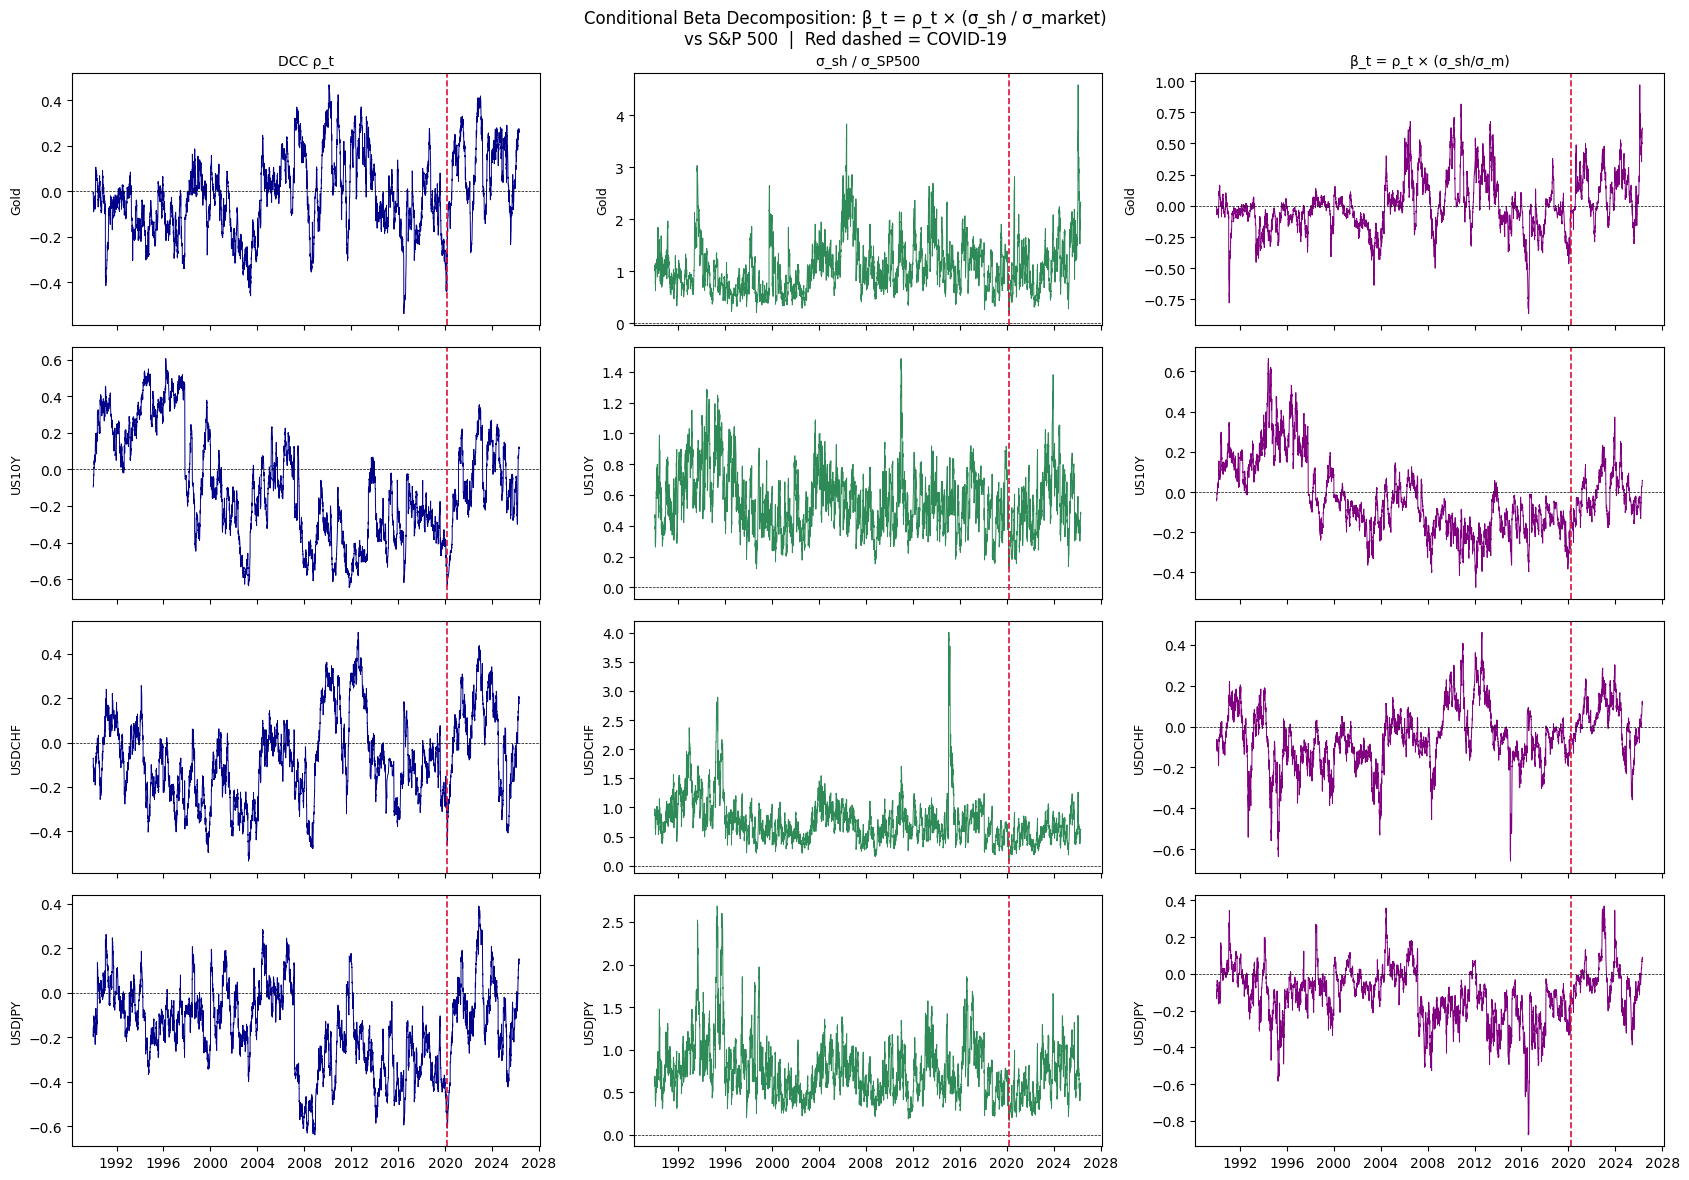

In [11]:
# Compute conditional beta for all pairs
dcc_beta_all = {}
for sh in safe_havens:
    sigma_sh = garch_full[sh].conditional_volatility.loc[std_resid.index]
    for bm in benchmarks:
        sigma_bm = garch_full[bm].conditional_volatility.loc[std_resid.index]
        key = f"{sh}_vs_{bm}"
        dcc_beta_all[key] = dcc_corr_all[key] * (sigma_sh / sigma_bm)

# ── Figure: beta decomposition vs SP500 ──────────────────────────────────────
fig, axes = plt.subplots(4, 3, figsize=(17, 12), sharex=True)
for i, sh in enumerate(safe_havens):
    key = f"{sh}_vs_SP500"
    rho_t    = dcc_corr_all[key]
    sigma_sh = garch_full[sh].conditional_volatility.loc[std_resid.index]
    sigma_sp = garch_full['SP500'].conditional_volatility.loc[std_resid.index]

    for ax, (data, title, color) in zip(axes[i], [
        (rho_t,               'DCC ρ_t',             'darkblue'),
        (sigma_sh / sigma_sp, 'σ_sh / σ_SP500',      'seagreen'),
        (dcc_beta_all[key],   'β_t = ρ_t × (σ_sh/σ_m)', 'purple'),
    ]):
        ax.plot(data.index, data.values, linewidth=0.7, color=color)
        ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
        ax.axvline(COVID_DATE, color='crimson', linestyle='--', linewidth=1.2)
        ax.set_ylabel(sh, fontsize=9)
        if i == 0: ax.set_title(title, fontsize=10)

plt.suptitle('Conditional Beta Decomposition: β_t = ρ_t × (σ_sh / σ_market)\n'
             'vs S&P 500  |  Red dashed = COVID-19', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/figures/conditional_beta.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 3.3 — Rolling 252-Day Correlation

A non-parametric counterpart to the DCC. The rolling correlation uses a fixed
252-day window (one trading year) and weights all observations equally — unlike
the DCC, which weights recent observations more heavily. If both series flag the
same structural break in Section 4, the result is robust to the choice of estimator.

We compute rolling correlations for all eight safe-haven / benchmark pairs.

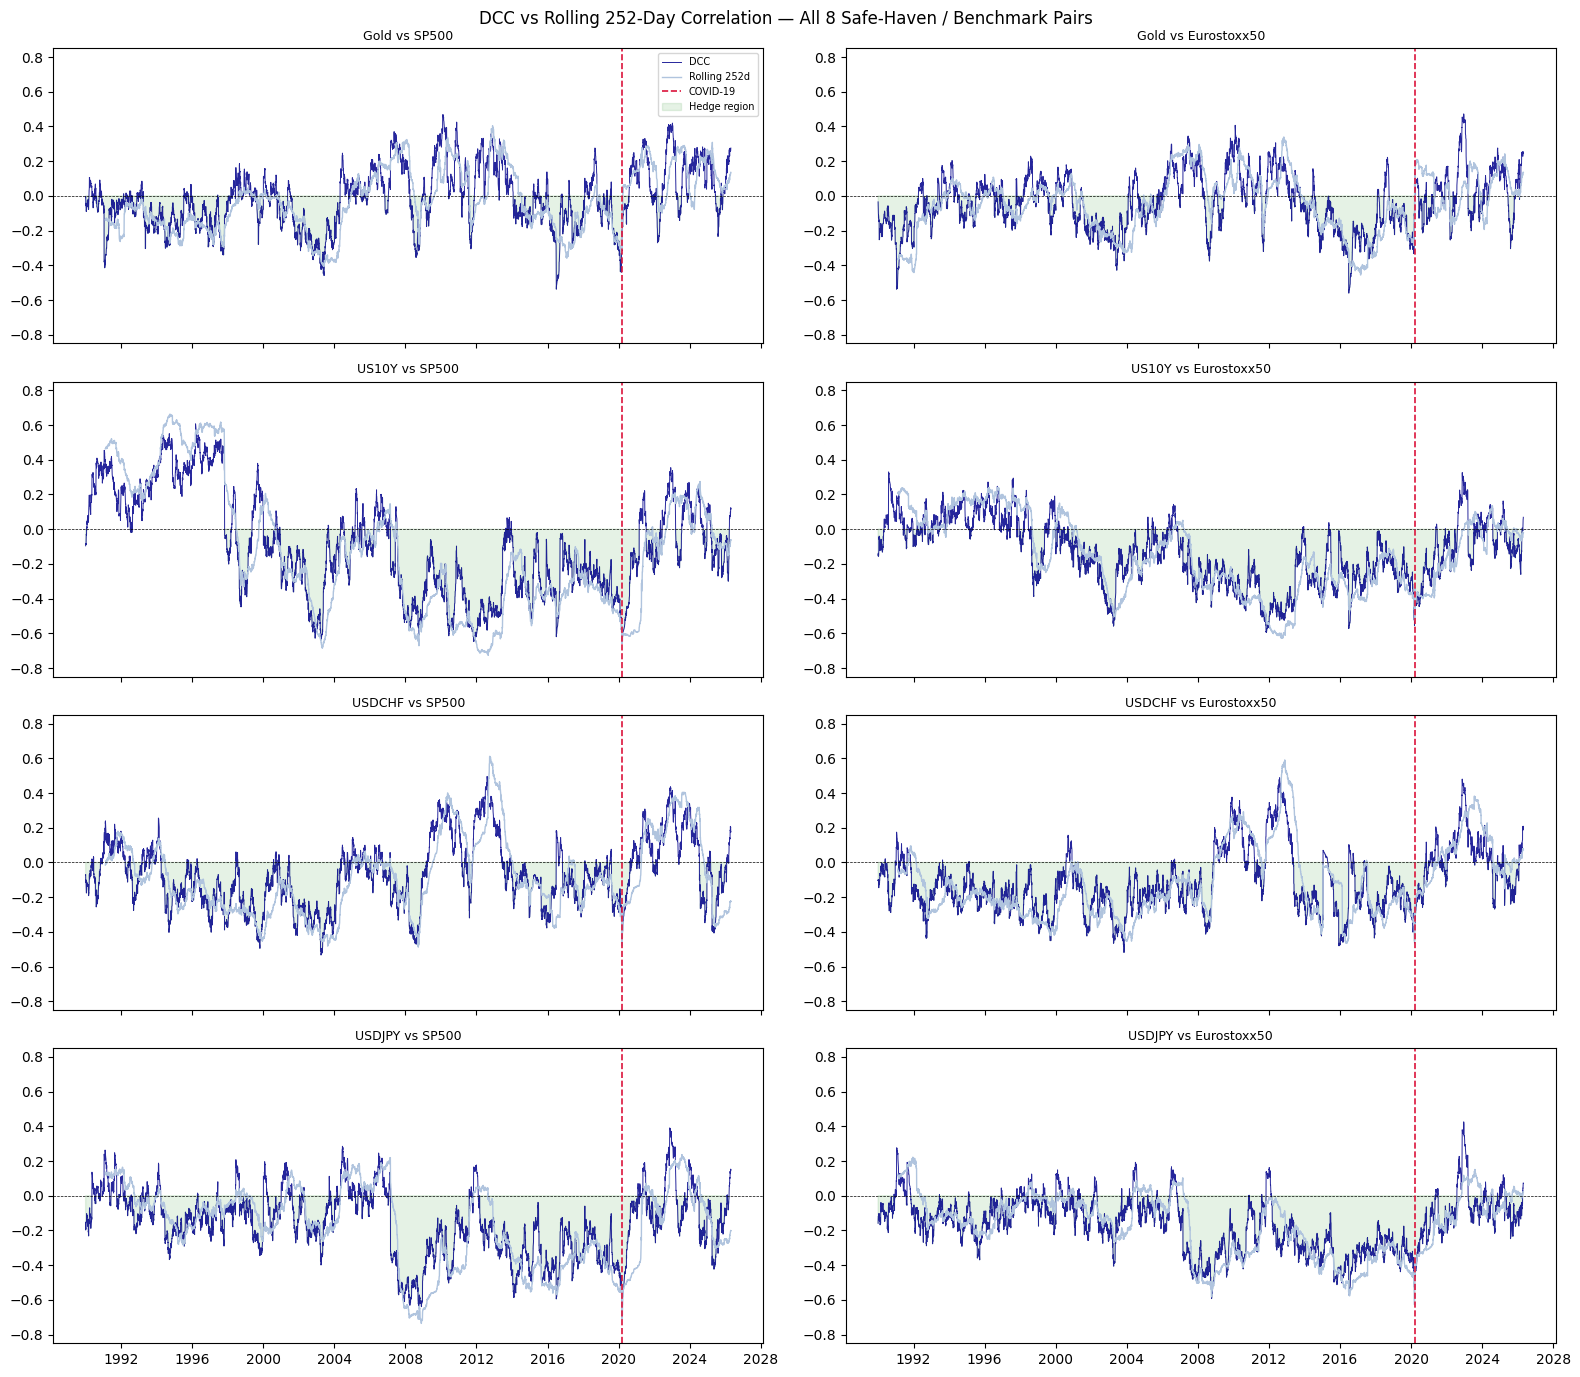

In [12]:
rolling_corr_all = {}
for sh in safe_havens:
    for bm in benchmarks:
        key = f"{sh}_vs_{bm}"
        rolling_corr_all[key] = (
            returns[sh].rolling(ROLL_WIN).corr(returns[bm]).dropna()
        )

# ── Figure: DCC vs rolling for all 8 pairs ────────────────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(16, 14), sharex=True)
for i, sh in enumerate(safe_havens):
    for j, bm in enumerate(benchmarks):
        key = f"{sh}_vs_{bm}"
        ax  = axes[i, j]
        ax.plot(dcc_corr_all[key].index, dcc_corr_all[key].values,
                color='darkblue', linewidth=0.7, label='DCC', alpha=0.85)
        ax.plot(rolling_corr_all[key].index, rolling_corr_all[key].values,
                color='lightsteelblue', linewidth=1.0, label='Rolling 252d')
        ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
        ax.axvline(COVID_DATE, color='crimson', linestyle='--',
                   linewidth=1.2, label='COVID-19')
        ax.fill_between(dcc_corr_all[key].index, dcc_corr_all[key].values, 0,
                        where=(dcc_corr_all[key].values < 0),
                        alpha=0.10, color='green', label='Hedge region')
        ax.set_ylim(-0.85, 0.85)
        ax.set_title(f'{sh} vs {bm}', fontsize=9)
        if i == 0 and j == 0:
            ax.legend(fontsize=7)

plt.suptitle('DCC vs Rolling 252-Day Correlation — All 8 Safe-Haven / Benchmark Pairs',
             fontsize=12)
plt.tight_layout()
plt.savefig('outputs/figures/correlations.png', dpi=150, bbox_inches='tight')
plt.show()

---

# 4. Structural Breaks & Regimes


## Step 4.2 — Structural Break Tests: sup-F then Bai-Perron

We apply two-stage structural break testing to each DCC correlation series.

**Stage 1 — sup-F (Quandt-Andrews test).** This preliminary test asks whether *any*
evidence of at least one break exists, without specifying the date or number. The
statistic is the supremum of Chow F-statistics across all admissible candidate dates
(excluding 15% from each end). Its critical values are non-standard (Andrews 1993)
because they account for the search: using ordinary F tables after searching would
systematically over-reject. For $k=1$ restriction (mean shift) and 15% trimming,
the 5% critical value is approximately 8.85. If sup-F fails to reject, we stop and
report no statistical evidence of a break for that pair.

**Stage 2 — Bai-Perron (1998, 2003).** For pairs where sup-F rejects, we apply
dynamic programming to find the globally optimal break dates by minimizing total SSR
across all segments simultaneously. The number of breaks is selected endogenously
by comparing total SSR for $m = 1, 2, 3$: we add a break only if it reduces SSR by
more than 15% relative to $m-1$ breaks. This is more rigorous than imposing a fixed
number in advance.

In [13]:
# ── sup-F test (Quandt-Andrews) — vectorized O(T) implementation ─────────────
# The naive loop version is O(T²): it recomputes SSR from scratch at every split
# point. Instead we use cumulative sums so every split is evaluated in O(1):
#   SSR(y[:t]) = Σy² - (Σy)²/t
# All split points are evaluated simultaneously with no Python loop.
def supF_test(series, trim=TRIM):
    y   = series.dropna().values
    T   = len(y)
    lo  = int(trim * T)
    hi  = T - int(trim * T)

    SSR_full = float(np.sum((y - y.mean())**2))

    # Precompute cumulative sums — O(T) once
    cs   = np.cumsum(y)           # cumulative sum of y
    cs2  = np.cumsum(y ** 2)      # cumulative sum of y²

    # Candidate split indices as a NumPy array
    t_arr = np.arange(lo, hi)     # shape (n_candidates,)
    n1    = t_arr                  # obs in pre-break segment
    n2    = T - t_arr              # obs in post-break segment

    # Sum of y and y² in each segment — O(1) per candidate via index lookup
    s1   = cs[t_arr - 1]
    s2   = cs[T - 1] - cs[t_arr - 1]
    s2_1 = cs2[t_arr - 1]
    s2_2 = cs2[T - 1] - cs2[t_arr - 1]

    # SSR = Σy² - (Σy)²/n  for each segment
    SSR1  = s2_1 - s1 ** 2 / n1
    SSR2  = s2_2 - s2 ** 2 / n2
    num   = (SSR_full - SSR1 - SSR2) / 1
    den   = (SSR1 + SSR2) / (T - 2)
    F_arr = np.where(den > 0, num / den, 0.0)

    best_local = int(np.argmax(F_arr))
    t_star     = int(t_arr[best_local])
    sup_F      = float(F_arr[best_local])
    all_dates  = series.dropna().index
    F_series   = pd.Series(F_arr, index=all_dates[t_arr], name='F_stat')
    return sup_F, t_star, all_dates[t_star], F_series


supF_results   = {}
bp_results     = {}

print("=" * 70)
print(f"STAGE 1 — sup-F  (Andrews 1993  5% CV = {SUPF_CV_5PCT})")
print("=" * 70)

PAIRS = [f"{sh}_vs_{bm}" for sh in safe_havens for bm in benchmarks]

for key in PAIRS:
    series = dcc_corr_all[key]
    sup_F, t_idx, date_star, F_series = supF_test(series)
    reject = sup_F > SUPF_CV_5PCT
    supF_results[key] = {'sup_F': sup_F, 'date': date_star, 'reject': reject}

    flag = '→ REJECT ✓  (break exists, proceed to Bai-Perron)' if reject else '→ fail to reject'
    print(f"\n{key}:")
    print(f"  sup-F = {sup_F:.2f}   {flag}")
    print(f"  sup-F estimated break: {date_star.date()}")

    if reject:
        # ── STAGE 2: Bai-Perron ───────────────────────────────────────────────
        y_bp  = series.dropna().values.reshape(-1, 1)
        idx_  = series.dropna().index
        # jump=5: consider every 5th obs as candidate break — 25x faster than
        # jump=1 with negligible loss in precision (5 days on a 36-year sample)
        model_bp = rpt.Dynp(model="l2", min_size=MIN_SEG_BP, jump=5).fit(y_bp)

        def total_ssr(bkps):
            segs = [0] + bkps
            ssr  = 0
            for k in range(len(segs) - 1):
                seg = y_bp[segs[k]:segs[k+1]]
                ssr += float(np.sum((seg - seg.mean())**2))
            return ssr

        ssr_by_m  = {0: total_ssr([len(y_bp)])}
        bkps_by_m = {}
        for m in [1, 2, 3]:
            bkps_m       = model_bp.predict(n_bkps=m)
            ssr_by_m[m]  = total_ssr(bkps_m)
            bkps_by_m[m] = bkps_m[:-1]   # drop sentinel

        # Sequential selection: keep adding breaks while SSR drops > 15%
        optimal_m = 0
        for m in [1, 2, 3]:
            reduction = (ssr_by_m[m-1] - ssr_by_m[m]) / ssr_by_m[m-1]
            if reduction > 0.15:
                optimal_m = m

        break_dates = [idx_[b] for b in bkps_by_m.get(optimal_m, [])]
        bp_results[key] = {'optimal_m': optimal_m, 'break_dates': break_dates,
                           'ssr_by_m': ssr_by_m}

        print(f"  Bai-Perron: optimal m = {optimal_m}")
        for m in range(1, 4):
            red = (ssr_by_m[m-1] - ssr_by_m[m]) / ssr_by_m[m-1] * 100
            print(f"    m={m}: SSR = {ssr_by_m[m]:.4f}  (−{red:.1f}% vs m−1)")
        for d in break_dates:
            print(f"  → Break detected: {d.date()}")
    else:
        bp_results[key] = {'optimal_m': 0, 'break_dates': [], 'ssr_by_m': {}}

# Save
bp_table = pd.DataFrame({
    k: [str(d.date()) for d in v['break_dates']] +
       [''] * (3 - len(v['break_dates']))
    for k, v in bp_results.items()
}, index=['Break 1', 'Break 2', 'Break 3']).T
bp_table.to_csv('outputs/tables/bai_perron_breaks.csv')
display(bp_table)

STAGE 1 — sup-F  (Andrews 1993  5% CV = 8.85)

Gold_vs_SP500:
  sup-F = 1934.49   → REJECT ✓  (break exists, proceed to Bai-Perron)
  sup-F estimated break: 2004-04-29
  Bai-Perron: optimal m = 3
    m=1: SSR = 208.1834  (−18.6% vs m−1)
    m=2: SSR = 194.3610  (−6.6% vs m−1)
    m=3: SSR = 158.8112  (−18.3% vs m−1)
  → Break detected: 2004-04-27
  → Break detected: 2014-01-22
  → Break detected: 2020-08-04

Gold_vs_Eurostoxx50:
  sup-F = 416.36   → REJECT ✓  (break exists, proceed to Bai-Perron)
  sup-F estimated break: 2020-10-29
  Bai-Perron: optimal m = 0
    m=1: SSR = 202.2916  (−6.3% vs m−1)
    m=2: SSR = 179.4962  (−11.3% vs m−1)
    m=3: SSR = 153.1235  (−14.7% vs m−1)

US10Y_vs_SP500:
  sup-F = 9213.59   → REJECT ✓  (break exists, proceed to Bai-Perron)
  sup-F estimated break: 1997-10-28
  Bai-Perron: optimal m = 3
    m=1: SSR = 353.7219  (−52.1% vs m−1)
    m=2: SSR = 287.9914  (−18.6% vs m−1)
    m=3: SSR = 226.2055  (−21.5% vs m−1)
  → Break detected: 1997-10-29
  → Bre

,Break 1,Break 2,Break 3
Gold_vs_SP500,2004-04-27,2014-01-22,2020-08-04
Gold_vs_Eurostoxx50,,,
US10Y_vs_SP500,1997-10-29,2007-08-08,2021-02-26
US10Y_vs_Eurostoxx50,2001-03-23,2021-10-27,
USDCHF_vs_SP500,2009-04-02,2013-05-21,
USDCHF_vs_Eurostoxx50,2008-11-14,2013-05-21,2020-09-24
USDJPY_vs_SP500,2007-03-01,2020-08-18,
USDJPY_vs_Eurostoxx50,2007-03-01,2021-01-26,


## Step 4.3 — Markov-Switching (2-State)

Unlike Bai-Perron, which detects permanent breaks, Markov switching models
**recurring** regimes — states the market can revisit multiple times. We fit a
two-state model with switching mean and switching variance on the rolling correlation
series (which provides a smoother signal for regime detection). State 1 is the
*hedging* regime (low or negative correlation) and State 2 is the *safe-haven
breakdown* regime (high positive correlation).

The Hamilton filter (1989) delivers the filtered probability $P(S_t = 2\mid \mathcal{F}_{t-1})$
in real time, which is directly actionable for a portfolio manager. The expected
duration of each regime is $D_i = 1/(1-p_{ii})$: a longer post-COVID duration for
the bad-hedge regime would indicate the market is spending structurally more time in it.

A short comment on TAR/SETAR: Lecture 12 introduced threshold AR models as an
alternative, with regime transitions driven by an observable threshold. Their key
limitation — noted explicitly in class — is that regime persistence is tied to the
autocorrelation of the threshold variable, providing no free parameter to model
duration independently. This is why we use Markov switching.

,,p11,p22,D1 (days),D2 (days)
Asset,Period,,,,
Gold,Pre-COVID,0.9936,0.9909,155.6,109.6
US10Y,Pre-COVID,0.9891,0.9896,91.5,95.9
USDCHF,Pre-COVID,0.9978,0.9952,456.2,210.3
USDJPY,Pre-COVID,0.9905,0.9900,105.6,100.0
Gold,Post-COVID,0.9879,0.9904,82.4,104.7
US10Y,Post-COVID,0.9926,0.9942,135.6,171.7
USDCHF,Post-COVID,0.9954,0.9943,215.7,174.7
USDJPY,Post-COVID,0.9880,0.9860,83.2,71.6


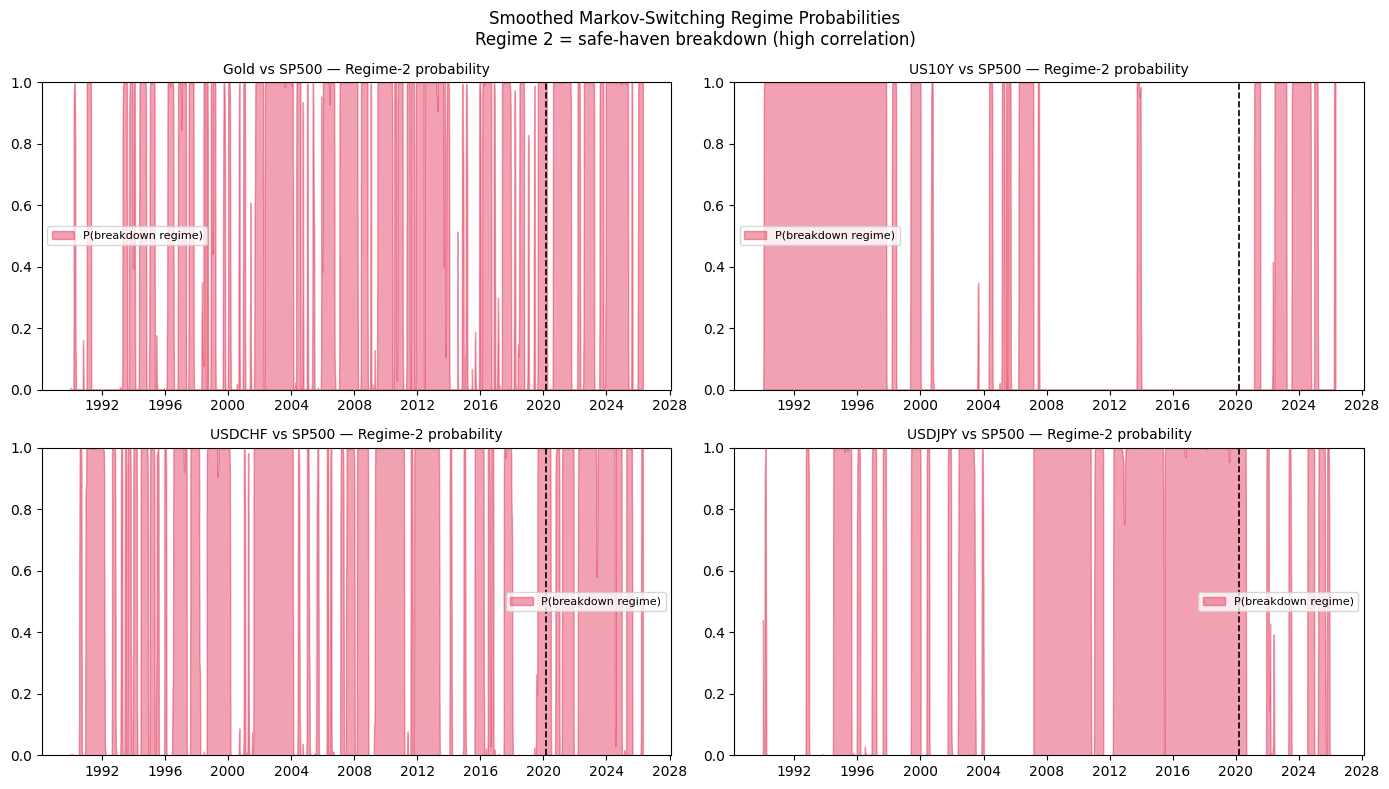

In [14]:
from statsmodels.tsa.regime_switching.markov_autoregression import MarkovAutoregression

def fit_ms(series):
    return MarkovRegression(series, k_regimes=2, trend='c', switching_variance=True).fit(disp=False, maxiter=300)

# Fit on DCC correlation (conditional, F_{t-1}-measurable signal)
ms_full = {}
ms_pre  = {}
ms_post = {}

for sh in safe_havens:
    # Use the SP500 pair as the primary series for regime detection
    key = f"{sh}_vs_SP500"
    s   = dcc_corr_all[key]
    try:
        ms_full[sh] = fit_ms(s)
        split = pd.Timestamp(SPLIT_DATE)

        ms_pre[sh]  = fit_ms(s.loc[MS_PRE_START:split])
        ms_post[sh] = fit_ms(s.loc[split:])
    except Exception as e:
        print(f"{sh}: MS failed — {e}")

# ── Table 4: MS parameters pre / post ─────────────────────────────────────────
def ms_row(res, asset, period):
    try:
        # regime_transition gives p[i,j] — rows = from, cols = to
        p11 = float(res.regime_transition[0, 0, 0])
        p22 = float(res.regime_transition[1, 1, 0])
    except Exception:
        # fallback: read from params directly
        p11 = res.params.get('p[0->0]', np.nan)
        p22 = res.params.get('p[1->1]', np.nan)
    return {
        'Asset': asset, 'Period': period,
        'p11': round(p11, 4), 'p22': round(p22, 4),
        'D1 (days)': round(1 / (1 - p11), 1) if p11 < 1 else np.nan,
        'D2 (days)': round(1 / (1 - p22), 1) if p22 < 1 else np.nan,
    }

table4 = pd.DataFrame(
    [ms_row(ms_pre[c],  c, 'Pre-COVID')  for c in safe_havens if c in ms_pre]  +
    [ms_row(ms_post[c], c, 'Post-COVID') for c in safe_havens if c in ms_post]
).set_index(['Asset', 'Period']).round(4)
display(table4)
table4.to_csv('outputs/tables/table4_ms_params.csv')

# ── Figure: smoothed regime-2 probabilities ───────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, sh in zip(axes.flat, safe_havens):
    if sh not in ms_full:
        continue
    try:
        probs = ms_full[sh].smoothed_marginal_probabilities.iloc[:, 1]
    except Exception:
        probs = ms_full[sh].smoothed_marginal_probabilities[1]
    ax.fill_between(probs.index, probs.values,
                    alpha=0.4, color='crimson', label='P(breakdown regime)')
    ax.axvline(COVID_DATE, color='black', linestyle='--', linewidth=1.2)
    ax.set_title(f'{sh} vs SP500 — Regime-2 probability', fontsize=10)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
plt.suptitle('Smoothed Markov-Switching Regime Probabilities\n'
             'Regime 2 = safe-haven breakdown (high correlation)', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/figures/smoothed_probs.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 4.4 — Wald Test: Did the Regime Structure Itself Change?

Structural break tests tell us *when* the correlation level shifted; Markov switching
tells us about recurring regime dynamics. But neither alone answers whether COVID
changed the fundamental nature of the regimes — not just which one the market visited,
but what each regime looks like.

We bridge the two analyses with a Wald test. Using the SPLIT_DATE = '2020-03-01' as the split point, we estimate the full Markov switching parameter vector
$\hat{\theta} = (\mu_1, \mu_2, \sigma_1, \sigma_2, p_{11}, p_{22})$ separately on
each subsample and test $H_0: \theta_{\text{pre}} = \theta_{\text{post}}$.

Since the two subsamples are independent, the variance of the parameter difference is
the sum of the two covariance matrices, and the Wald statistic
$W = (\hat{\theta}_{\text{pre}} - \hat{\theta}_{\text{post}})^\top
     [\hat{V}_{\text{pre}} + \hat{V}_{\text{post}}]^{-1}
     (\hat{\theta}_{\text{pre}} - \hat{\theta}_{\text{post}}) \sim \chi^2(k)$
under $H_0$, where $k$ is the number of parameters.

**Interpretation:**
- If we *reject* $H_0$: the regime dynamics themselves changed post-COVID — the bear
  regime has a different volatility, mean, or persistence. This is a structural change
  in the full sense.
- If we *fail to reject* $H_0$: the same two regimes existed before and after COVID;
  what changed was only the frequency or duration of visits to the bad-hedge regime.


In [15]:
def align_ms_params(res):
    theta = res.params.values.copy()
    V = res.cov_params().values.copy()
    idx = list(res.params.index)
    c0_idx = idx.index('const[0]')
    c1_idx = idx.index('const[1]')
    if theta[c0_idx] > theta[c1_idx]:
        n = len(theta)
        J = np.zeros((n, n))
        new_theta = theta.copy()
        for name in idx:
            src_idx = idx.index(name)

            if name == 'p[0->0]':
                dest_idx = idx.index('p[1->0]')
                new_theta[dest_idx] = 1.0 - theta[src_idx]
                J[dest_idx, src_idx] = -1.0

            elif name == 'p[1->0]':
                dest_idx = idx.index('p[0->0]')
                new_theta[dest_idx] = 1.0 - theta[src_idx]
                J[dest_idx, src_idx] = -1.0

            elif name.endswith('[0]'):
                dest_name = name[:-3] + '[1]'
                dest_idx = idx.index(dest_name)
                new_theta[dest_idx] = theta[src_idx]
                J[dest_idx, src_idx] = 1.0

            elif name.endswith('[1]'):
                dest_name = name[:-3] + '[0]'
                dest_idx = idx.index(dest_name)
                new_theta[dest_idx] = theta[src_idx]
                J[dest_idx, src_idx] = 1.0

            else:
                J[src_idx, src_idx] = 1.0

        new_V = J @ V @ J.T
        return new_theta, new_V
    else:
        return theta, V

print("=" * 70)
print("WALD TEST: H₀ — Markov switching parameters stable across break date")
print("=" * 70)

# One-time check: confirm statsmodels parameter naming matches what align_ms_params expects.
# Remove this print before final submission.
print("MS param names:", list(ms_full[safe_havens[0]].params.index))

wald_results = {}

for sh in safe_havens:
    key    = f"{sh}_vs_SP500"
    split  = pd.Timestamp(SPLIT_DATE)
    s_full = dcc_corr_all[key]
    s_pre  = s_full.loc[MS_PRE_START:split]
    s_post = s_full.loc[split:]

    print(f"\n{sh}  (split at {split.date()}, "
          f"pre={len(s_pre)} obs, post={len(s_post)} obs)")

    if len(s_pre) < 60 or len(s_post) < 60:
        print(f"  Insufficient observations — skipping")
        continue

    try:
        ms_pre_wald  = fit_ms(s_pre)
        ms_post_wald = fit_ms(s_post)

        theta_pre_aligned, V_pre_aligned = align_ms_params(ms_pre_wald)
        theta_post_aligned, V_post_aligned = align_ms_params(ms_post_wald)
        diff       = theta_pre_aligned - theta_post_aligned

        V_sum      = V_pre_aligned + V_post_aligned
        W          = float(diff @ np.linalg.pinv(V_sum) @ diff)
        k  = len(diff)
        pv = 1 - stats.chi2.cdf(W, df=k)

        print(f"  Wald W = {W:.2f},  k = {k},  p = {pv:.4f}", end='  ')
        if pv < 0.05:
            print("→ REJECT H₀: regime structure changed — structural break in regime dynamics")
        else:
            print("→ fail to reject H₀: same regime dynamics, "
                  "market spent more time in bad-hedge regime post-COVID")

        # Compare expected duration of bad-hedge regime
        idx = list(ms_pre_wald.params.index)
        p10_idx = idx.index('p[1->0]')
        p22_pre  = 1.0 - theta_pre_aligned[p10_idx]
        p22_post = 1.0 - theta_post_aligned[p10_idx]
        print(f"  E[duration bad regime]: pre = {1/(1-p22_pre):.1f} days, "
              f"post = {1/(1-p22_post):.1f} days")

        wald_results[sh] = {'W': W, 'k': k, 'p': pv,
                            'D_bad_pre': 1/(1-p22_pre),
                            'D_bad_post': 1/(1-p22_post)}

    except Exception as e:
        print(f"  Estimation failed: {e}")

wald_table = pd.DataFrame(wald_results).T.round(3)
display(wald_table)
wald_table.to_csv('outputs/tables/wald_ms.csv')

WALD TEST: H₀ — Markov switching parameters stable across break date
MS param names: ['p[0->0]', 'p[1->0]', 'const[0]', 'const[1]', 'sigma2[0]', 'sigma2[1]']

Gold  (split at 2020-03-01, pre=2381 obs, post=1438 obs)
  Wald W = 458.42,  k = 6,  p = 0.0000  → REJECT H₀: regime structure changed — structural break in regime dynamics
  E[duration bad regime]: pre = 109.6 days, post = 104.7 days

US10Y  (split at 2020-03-01, pre=2381 obs, post=1438 obs)
  Wald W = 6141.29,  k = 6,  p = 0.0000  → REJECT H₀: regime structure changed — structural break in regime dynamics
  E[duration bad regime]: pre = 91.5 days, post = 135.6 days

USDCHF  (split at 2020-03-01, pre=2381 obs, post=1438 obs)
  Wald W = 188.16,  k = 6,  p = 0.0000  → REJECT H₀: regime structure changed — structural break in regime dynamics
  E[duration bad regime]: pre = 210.3 days, post = 215.7 days

USDJPY  (split at 2020-03-01, pre=2381 obs, post=1438 obs)
  Wald W = 6178.67,  k = 6,  p = 0.0000  → REJECT H₀: regime structure 

,W,k,p,D_bad_pre,D_bad_post
Gold,458.422,6.0,0.0,109.631,104.692
US10Y,6141.293,6.0,0.0,91.542,135.596
USDCHF,188.155,6.0,0.0,210.314,215.693
USDJPY,6178.673,6.0,0.0,105.619,71.629


---

# 5. Economic Magnitude of the Covariance Shift

The DCC and structural break results document *that* correlations changed post-COVID
and *when*. This block quantifies *how much it mattered* in economic terms.

We use **Equal Risk Contribution (ERC)** weights — purely covariance-driven,
no expected return assumptions, no regime classification. ERC weights are the
natural benchmark because they represent a risk-balanced investor whose only
input is $\Sigma$.

The **cost of inaction** is then:

$$\text{Cost} = \sqrt{w_{pre}^\top \Sigma_{post}\, w_{pre}} - \sqrt{w_{post}^\top \Sigma_{post}\, w_{post}}$$

This measures how much extra annualised portfolio volatility a pre-COVID
risk-balanced investor would have borne post-COVID by failing to update their
allocation — a direct monetary consequence of the correlation shift we documented.

In [16]:
from scipy.optimize import minimize as sp_min

N       = returns.shape[1]
w0      = np.ones(N) / N
bounds  = tuple((0.0, 0.70) for _ in range(N))
cons_sum = {'type': 'eq', 'fun': lambda w: w.sum() - 1.0}

def erc_objective(w, cov):
    """Minimize variance of risk contributions across assets."""
    port_vol = np.sqrt(w @ cov @ w)
    mrc = (cov @ w) / port_vol       # marginal risk contribution
    rc  = w * mrc                     # risk contribution per asset
    return ((rc - rc.mean()) ** 2).sum()

cov_pre  = ret_pre.cov().values   * 252   # annualised
cov_post = ret_post.cov().values  * 252   # annualised

w_pre  = sp_min(erc_objective, w0, args=(cov_pre,),
                bounds=bounds, constraints=cons_sum, method='SLSQP').x
w_post = sp_min(erc_objective, w0, args=(cov_post,),
                bounds=bounds, constraints=cons_sum, method='SLSQP').x

# ── ERC weights pre vs post ───────────────────────────────────────────────
erc_weights = pd.DataFrame(
    {'Pre-COVID': w_pre, 'Post-COVID': w_post},
    index=returns.columns
).round(4)
print('ERC weights — Pre vs Post COVID:')
display(erc_weights)
erc_weights.to_csv('outputs/tables/erc_weights.csv')

# ── Cost of inaction ──────────────────────────────────────────────────────
# How much extra annualised vol does a pre-COVID allocation incur post-COVID?
vol_pre_on_pre   = np.sqrt(w_pre  @ cov_pre  @ w_pre)    # pre weights, pre Σ
vol_post_on_post = np.sqrt(w_post @ cov_post @ w_post)   # post weights, post Σ
vol_pre_on_post  = np.sqrt(w_pre  @ cov_post @ w_pre)    # pre weights, post Σ ← inaction

cost = vol_pre_on_post - vol_post_on_post

print(f'\nAnnualised portfolio vol:')
print(f'  Pre weights  × Pre  Σ : {vol_pre_on_pre*100:.2f}%  (in-sample baseline)')
print(f'  Post weights × Post Σ : {vol_post_on_post*100:.2f}%  (optimal post-COVID)')
print(f'  Pre weights  × Post Σ : {vol_pre_on_post*100:.2f}%  (cost of inaction)')
print(f'\nCost of not updating allocation: +{cost*100:.2f}% annualised volatility')

pd.DataFrame([{
    'vol_pre_on_pre':   round(vol_pre_on_pre*100,   2),
    'vol_post_on_post': round(vol_post_on_post*100, 2),
    'vol_pre_on_post':  round(vol_pre_on_post*100,  2),
    'cost_bps':         round(cost*10000,           1),
}]).to_csv('outputs/tables/cost_of_inaction.csv', index=False)


ERC weights — Pre vs Post COVID:


,Pre-COVID,Post-COVID
SP500,0.1334,0.1101
Eurostoxx50,0.1092,0.1114
Gold,0.1202,0.1042
US10Y,0.2988,0.2606
USDCHF,0.1542,0.2172
USDJPY,0.1842,0.1964



Annualised portfolio vol:
  Pre weights  × Pre  Σ : 560.43%  (in-sample baseline)
  Post weights × Post Σ : 696.34%  (optimal post-COVID)
  Pre weights  × Post Σ : 715.71%  (cost of inaction)

Cost of not updating allocation: +19.37% annualised volatility


---

# 6. Results Summary

Consolidated table: sup-F break detection, Bai-Perron break dates, Markov switching
expected durations, and Wald test verdict — all eight safe-haven / benchmark pairs.

In [17]:
summary = []
for key in PAIRS:
    sh, bm = key.split('_vs_')
    sup    = supF_results.get(key, {})
    bp     = bp_results.get(key, {})
    wd     = wald_results.get(sh, {}) if bm == 'SP500' else {}
    bd_str = ', '.join(str(d.date()) for d in bp.get('break_dates', [])) or 'None'

    summary.append({
        'Pair':            key,
        'sup-F stat':      round(sup.get('sup_F', np.nan), 2),
        'Break detected':  'Yes' if sup.get('reject') else 'No',
        'BP breaks (m)':   bp.get('optimal_m', 0),
        'Break date(s)':   bd_str,
        'Wald p':          round(wd.get('p', np.nan), 4),
        'E[D_bad] pre (d)':  round(wd.get('D_bad_pre',  np.nan), 1),
        'E[D_bad] post (d)': round(wd.get('D_bad_post', np.nan), 1),
    })

summary_df = pd.DataFrame(summary)
print("\n" + "="*80 + "\nFINAL RESULTS SUMMARY\n" + "="*80)
display(summary_df.set_index('Pair'))
summary_df.to_csv('outputs/tables/results_summary.csv', index=False)
print("\nAll outputs saved to outputs/tables/ and outputs/figures/")


FINAL RESULTS SUMMARY


,sup-F stat,Break detected,BP breaks (m),Break date(s),Wald p,E[D_bad] pre (d),E[D_bad] post (d)
Pair,,,,,,,
Gold_vs_SP500,1934.49,Yes,3,"2004-04-27, 2014-01-22, 2020-08-04",0.0,109.6,104.7
Gold_vs_Eurostoxx50,416.36,Yes,0,None,NaN,NaN,NaN
US10Y_vs_SP500,9213.59,Yes,3,"1997-10-29, 2007-08-08, 2021-02-26",0.0,91.5,135.6
US10Y_vs_Eurostoxx50,5044.67,Yes,2,"2001-03-23, 2021-10-27",NaN,NaN,NaN
USDCHF_vs_SP500,1671.27,Yes,2,"2009-04-02, 2013-05-21",0.0,210.3,215.7
USDCHF_vs_Eurostoxx50,1722.63,Yes,3,"2008-11-14, 2013-05-21, 2020-09-24",NaN,NaN,NaN
USDJPY_vs_SP500,2459.78,Yes,2,"2007-03-01, 2020-08-18",0.0,105.6,71.6
USDJPY_vs_Eurostoxx50,2325.93,Yes,2,"2007-03-01, 2021-01-26",NaN,NaN,NaN



All outputs saved to outputs/tables/ and outputs/figures/
